In [43]:
# 1) Environment & versions
import sys
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn may not be installed in some kernels; attempt import and fallback to pip install
try:
    import seaborn as sns
except ModuleNotFoundError:
    print("seaborn not found. Attempting to install via pip...")
    try:
        get_ipython().run_line_magic('pip', 'install seaborn')
        import seaborn as sns
    except Exception as e:
        print("Automatic install failed:", e)
        print("Please install seaborn in your environment (pip install seaborn) and re-run this cell.")

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

%matplotlib inline

Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
scikit-learn: 1.6.1


In [44]:
# 2) Load dataset (read-only)
from pathlib import Path
DATA_PATH = Path('sri_lanka_paint_dataset_1000.csv')  # file is expected in backend/
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (4000, 5)


,WallSize_sqft,PricePerSqft_LKR,Location,PaintBrand,PaintGrade
0,142,76,wood,Nippon Water Base,Premium
1,237,50,wood,Nippolac Water Based,Economy
2,219,85,outdoor,Nippon Flex 100,Standard
3,122,119,floor,Robbialac,Premium
4,367,41,indoor,Dulux,Economy


In [45]:
# 3) Inspect dataset structure
print('\nColumns:')
print(df.columns.tolist())

print('\nInfo:')
df.info()

print('\nDtypes:')
print(df.dtypes)


Columns:
['WallSize_sqft', 'PricePerSqft_LKR', 'Location', 'PaintBrand', 'PaintGrade']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   WallSize_sqft     4000 non-null   int64 
 1   PricePerSqft_LKR  4000 non-null   int64 
 2   Location          4000 non-null   object
 3   PaintBrand        4000 non-null   object
 4   PaintGrade        4000 non-null   object
dtypes: int64(2), object(3)
memory usage: 156.4+ KB

Dtypes:
WallSize_sqft        int64
PricePerSqft_LKR     int64
Location            object
PaintBrand          object
PaintGrade          object
dtype: object


In [46]:
# 4) Basic in-memory cleaning & missing values
# Strip whitespace from object columns to normalize
text_cols = df.select_dtypes(include='object').columns.tolist()
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

print('\nMissing values per column:')
print(df.isna().sum())

# Example in-memory imputation decision (no write-back to CSV)
# We'll rely on SimpleImputer later in the pipeline for formal handling



Missing values per column:
WallSize_sqft       0
PricePerSqft_LKR    0
Location            0
PaintBrand          0
PaintGrade          0
dtype: int64


Numeric columns: ['WallSize_sqft', 'PricePerSqft_LKR']
Categorical columns: ['Location', 'PaintBrand', 'PaintGrade']


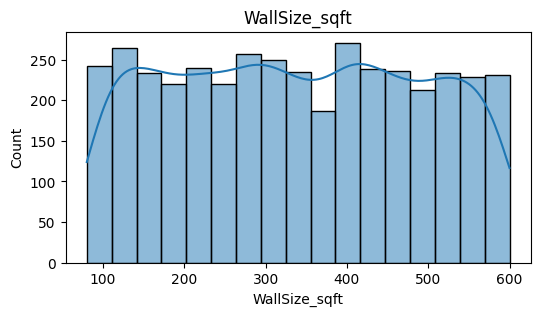

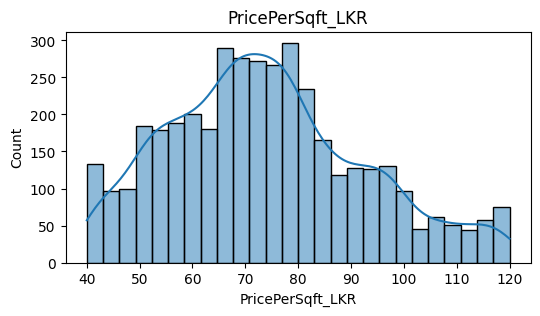


Value counts for Location
Location
indoor     1036
floor      1000
outdoor     985
wood        979
Name: count, dtype: int64

Value counts for PaintBrand
PaintBrand
Robbialac                   314
Nippon Water Base           211
Robbialac Water Base        210
JAT Water Base              195
Nippolac Water Based        183
Dulux Water Base            180
Dulux                       176
JAT                         173
Multilac                    171
Asian Paints Causeway       167
Nippon                      164
Nippon Epoxy                137
Nippon Floor Wax Polish     134
Lankem Robbialac            127
Nippon Water Based          124
Nippon Floor Paint          123
Causeway                    121
Dulux QD Floor Paints       105
Dulux Weathershield          66
WAPP Waterproofing Paint     61
Name: count, dtype: int64

Value counts for PaintGrade
PaintGrade
Premium     1391
Economy     1334
Standard    1275
Name: count, dtype: int64


In [47]:
# 5) Exploratory data analysis (examples)
num_cols = df.select_dtypes(include=['int','float']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

# Numeric distributions (first 4 numeric columns)
for c in num_cols[:4]:
    plt.figure(figsize=(6,3))
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(c)
    plt.show()

# Categorical counts for top categorical columns
for c in cat_cols[:4]:
    print('\nValue counts for', c)
    print(df[c].value_counts().head(20))


In [48]:
# 6) Define features (X) and target (y) and infer problem type
# Heuristics: prefer column named 'Brand' for classification; fall back to other choices
if 'Brand' in df.columns:
    target = 'Brand'
elif 'PricePerSqft_LKR' in df.columns:
    target = 'PricePerSqft_LKR'
elif 'Price' in df.columns:
    target = 'Price'
else:
    # pick a column with <=20 unique values as candidate classification target
    candidate = None
    for c in df.columns:
        if df[c].nunique() <= 20 and df[c].dtype == 'object':
            candidate = c
            break
    if candidate:
        target = candidate
    else:
        # fallback to the last numeric column
        num_cols = df.select_dtypes(include=['number']).columns
        target = num_cols[-1] if len(num_cols)>0 else df.columns[-1]

print('Selected target:', target)

y = df[target]
X = df.drop(columns=[target])

# determine problem type
is_classification = (y.dtype == 'object') or (y.nunique() < 50 and y.dtype != 'float')
print('Problem type inferred:', 'classification' if is_classification else 'regression')
print('Feature shape:', X.shape)


Selected target: PricePerSqft_LKR
Problem type inferred: regression
Feature shape: (4000, 4)


In [49]:
# 7) Train / test split
from sklearn.model_selection import train_test_split

if is_classification:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (3200, 4) Test: (800, 4)


In [50]:
# 8) Preprocessing pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = X_train.select_dtypes(include=['int','float']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
# Use dense output from OneHotEncoder to avoid "sparse data was passed" errors
cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')),('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocess = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', cat_transformer, categorical_features)])

print('Numeric:', numeric_features)
print('Categorical:', categorical_features)


Numeric: ['WallSize_sqft']
Categorical: ['Location', 'PaintBrand', 'PaintGrade']


In [51]:
# 9) Model candidates (conditional)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.svm import LinearSVC

if is_classification:
    models = {
        'Logistic Regression': LogisticRegression(max_iter=3000),
        'Linear SVM': LinearSVC(max_iter=3000),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': HistGradientBoostingClassifier(random_state=42)
    }
else:
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': HistGradientBoostingRegressor(random_state=42)
    }

models

{'Linear Regression': LinearRegression(),
 'Random Forest': RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 'Gradient Boosting': HistGradientBoostingRegressor(random_state=42)}

In [52]:
# 10) Cross-validation & metric selection
from sklearn.model_selection import cross_validate
import numpy as np

if is_classification:
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'f1_macro']
else:
    from sklearn.model_selection import KFold
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['neg_root_mean_squared_error', 'r2']

results = []
from sklearn.pipeline import Pipeline
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    entry = {'Model': name}
    if is_classification:
        entry['CV Accuracy (Mean)'] = scores['test_accuracy'].mean()
        entry['CV Macro F1 (Mean)'] = scores['test_f1_macro'].mean()
    else:
        entry['CV RMSE (Mean)'] = -scores['test_neg_root_mean_squared_error'].mean()
        entry['CV R2 (Mean)'] = scores['test_r2'].mean()
    results.append(entry)

results_df = pd.DataFrame(results)
results_df

,Model,CV RMSE (Mean),CV R2 (Mean)
0,Linear Regression,4.327102,0.944634
1,Random Forest,4.180847,0.948362
2,Gradient Boosting,3.882944,0.955426


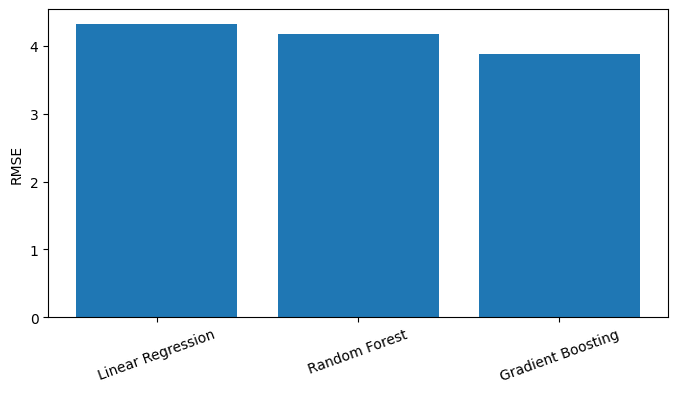

In [53]:
# 11) Visualize CV results
import matplotlib.pyplot as plt

if is_classification:
    plt.figure(figsize=(8,4))
    plt.bar(results_df['Model'], results_df['CV Accuracy (Mean)'], alpha=0.6, label='Accuracy')
    plt.bar(results_df['Model'], results_df['CV Macro F1 (Mean)'], alpha=0.6, label='Macro F1')
    plt.xticks(rotation=20)
    plt.legend()
    plt.show()
else:
    plt.figure(figsize=(8,4))
    plt.bar(results_df['Model'], results_df['CV RMSE (Mean)'])
    plt.xticks(rotation=20)
    plt.ylabel('RMSE')
    plt.show()


In [54]:
# 12) Train best model on full training set and save pipeline
from joblib import dump
from pathlib import Path
from sklearn.pipeline import Pipeline

# pick best model according to our primary metric
if is_classification:
    best_name = results_df.sort_values('CV Macro F1 (Mean)', ascending=False).iloc[0]['Model']
else:
    best_name = results_df.sort_values('CV RMSE (Mean)').iloc[0]['Model']

print('Selected model:', best_name)

best_model = models[best_name]
best_pipeline = Pipeline(steps=[('preprocess', preprocess), ('model', best_model)])
best_pipeline.fit(X_train, y_train)

# Save pipeline
Path('models').mkdir(parents=True, exist_ok=True)
model_path = Path('models') / f'sri_lanka_paint_pipeline_{best_name.replace(" ","_")}.joblib'
dump(best_pipeline, model_path)
print('Saved pipeline to', model_path)


Selected model: Gradient Boosting
Saved pipeline to models\sri_lanka_paint_pipeline_Gradient_Boosting.joblib


In [55]:
# 13) Final test evaluation
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error, r2_score, mean_absolute_error

y_pred = best_pipeline.predict(X_test)

if is_classification:
    print('Test Accuracy:', accuracy_score(y_test, y_pred))
    print('Test Macro F1:', f1_score(y_test, y_pred, average='macro'))
    print('\nClassification Report:\n', classification_report(y_test, y_pred))
else:
    # compute RMSE via sqrt of MSE to avoid compatibility issues with sklearn versions
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    print('Test RMSE:', rmse)
    print('Test MAE:', mean_absolute_error(y_test, y_pred))
    print('Test R2:', r2_score(y_test, y_pred))

Test RMSE: 3.9146206016883425
Test MAE: 3.228636455161978
Test R2: 0.9550555620050043


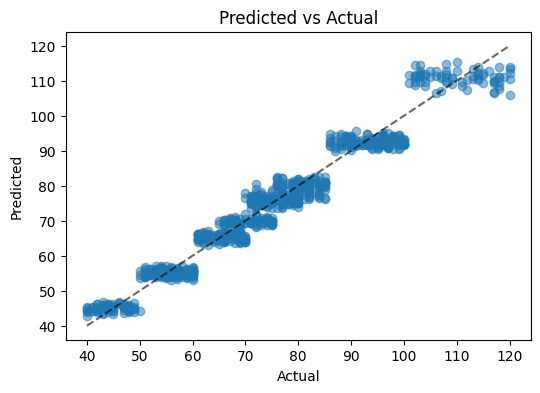

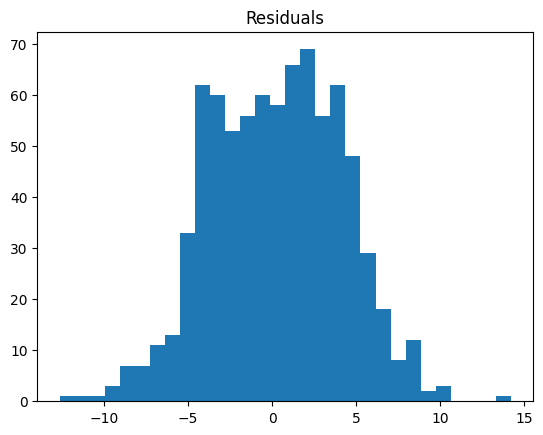

In [56]:
# 14) Confusion matrix or residual plot
import matplotlib.pyplot as plt

if is_classification:
    from sklearn.metrics import ConfusionMatrixDisplay
    labels = sorted(y_test.unique()) if hasattr(y_test, 'unique') else None
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=labels)
    plt.title('Confusion Matrix')
    plt.show()
else:
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs Actual')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.6)
    plt.show()

    plt.figure()
    plt.hist((y_test - y_pred), bins=30)
    plt.title('Residuals')
    plt.show()

In [57]:
# 15) Inference helper
import pandas as pd

def predict_from_dict(pipeline, input_dict):
    row = pd.DataFrame([input_dict])
    # Ensure columns align with training features
    missing_cols = [c for c in X.columns if c not in row.columns]
    for c in missing_cols:
        row[c] = None
    row = row[X.columns]
    return pipeline.predict(row)

# Example sample input (replace values with real ones from dataset columns)
sample = {c: X.iloc[0][c] if c in X.columns else None for c in (X.columns[:8])}
print('Sample prediction:', predict_from_dict(best_pipeline, sample))

Sample prediction: [74.51532359]


In [58]:
# 17) Unit test scaffold (writes a pytest test file)
# Create tests directory and a basic pytest file that checks pipeline predict shape
from pathlib import Path
Path('tests').mkdir(exist_ok=True)

test_file = Path('tests/test_paint_pipeline.py')

test_file.write_text('''import pandas as pd
from joblib import load

pipeline = load('models/sri_lanka_paint_pipeline_{}.joblib'.format(""))

def test_pipeline_predict_shape():
    # create a minimal input using columns order saved in the notebook
    # Note: replace with real sample values from dataset
    x = pd.DataFrame([{'dummy': None}])
    # This test should be updated with real sample input when integrating
    assert hasattr(pipeline, 'predict')
''')
print('Wrote', test_file)


Wrote tests\test_paint_pipeline.py


# 18) Notes & next steps
"""
- Confirm the selected target and update sample inputs for tests
- Add more EDA and feature engineering specific to paint data (color, finish, etc.)
- Consider stratified sampling for rare classes
- When happy, move pipeline saving to a versioned location (models/v1/)
"""